## Training the Vision Transformer on a Custom Dataset

In this notebook, we are going to fine-tune a pre-trained Vision Transformer (which can be found from [Huggingface](https://github.com/huggingface/transformers)) on a Custom Dataset. For this notebook we will be using the Rock, Paper, Scissors dataset which can be found [here](https://public.roboflow.com/classification/rock-paper-scissors/1). This dataset is a collection of 2925 images images in 3 different classes. This tutorial is based on Huggingface's [Fine tuning the Vision Transformer on CIFAR 10 notebook](https://colab.research.google.com/github/NielsRogge/Transformers-Tutorials/blob/master/VisionTransformer/Fine_tuning_the_Vision_Transformer_on_CIFAR_10_with_the_%F0%9F%A4%97_Trainer.ipynb).

### Accompanying Blog Post

We recommend that you follow along in this notebook while reading the blog post on [How to Train the HuggingFace Vision Transformer On a Custom Dataset](blog.roboflow.com/how-to-train-the-huggingface-vision-transformer-on-a-custom-dataset/) concurrently.


We will prepare the data using [Roboflow's Preprocessing Tools](https://docs.roboflow.com/image-transformations/image-preprocessing), and train the model using this notebook.

### Steps Covered in this Tutorial

In this tutorial, we will walk through the steps required to train a Vision Transformer on your custom classification data.

To train our image classifier we take the following steps:

* Install Vision Transformer dependencies
* Download custom Image Classification data using Roboflow
* Use the Vision Transformer Feature Extractor
* Run the Vision Transformer training procedure
* Evaluate the Vision Transformer on a test image
* Export the Vision Transformer model for future inference


### **About**

[Roboflow](https://roboflow.com) enables teams to deploy custom computer vision models quickly and accurately. Convert data from to annotation format, assess dataset health, preprocess, augment, and more. It's free for your first 1000 source images.

**Looking for a vision model available via API without hassle? Try Roboflow Train.**

![Roboflow Wordmark](https://i.imgur.com/dcLNMhV.png)



Let's start by installing the relevant libraries.

In [ ]:
!pip install -q git+https://github.com/huggingface/transformers

  Installing build dependencies ... canceled
ERROR: Operation cancelled by user


# Download the Data

We'll preprocess and download our dataset from Roboflow. To preprocess the images, change the size of the image to 224x224. To download the dataset, use the "**Folder Structure**" export format.

To get your data into Roboflow, follow the [Getting Started Guide](https://blog.roboflow.ai/getting-started-with-roboflow/).

Note: This data has already been preprocessed through Roboflow; we HIGHLY reccommend you follow the [accompanying blog](blog.roboflow.com/how-to-train-the-huggingface-vision-transformer-on-a-custom-dataset/) as you go through this notebook.

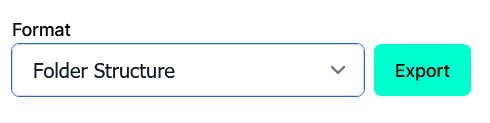

In [ ]:
!curl -L "https://app.roboflow.com/ds/5KObkCaKGq?key=nAJuoBkz4V" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   903  100   903    0     0   1931      0 --:--:-- --:--:-- --:--:--  1929
^C


Next, convert the folder structure dataset into a PyTorch dataset format using PyTorch's ImageFolder dataset structure:

In [ ]:
import torchvision
from torchvision.transforms import ToTensor

train_ds = torchvision.datasets.ImageFolder('/content/train/', transform=ToTensor())
valid_ds = torchvision.datasets.ImageFolder('/content/valid/', transform=ToTensor())
test_ds = torchvision.datasets.ImageFolder('/content/test/', transform=ToTensor())

KeyboardInterrupt: 

## Define the Model

Here we define the model.

The model itself uses a linear layer on top of a pre-trained `ViTModel`. We place a linear layer on top of the last hidden state of the [CLS] token, which serves as a good representation of an entire image. We also add dropout for regularization.

**Note:** The Vision Transformer pretrained model can be used as a regular PyTorch layer.

In [ ]:
from transformers import ViTModel
from transformers.modeling_outputs import SequenceClassifierOutput
import torch.nn as nn
import torch.nn.functional as F

class ViTForImageClassification(nn.Module):
    def __init__(self, num_labels=3):
        super(ViTForImageClassification, self).__init__()
        self.vit = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.vit.config.hidden_size, num_labels)
        self.num_labels = num_labels

    def forward(self, pixel_values, labels):
        outputs = self.vit(pixel_values=pixel_values)
        output = self.dropout(outputs.last_hidden_state[:,0])
        logits = self.classifier(output)

        loss = None
        if labels is not None:
          loss_fct = nn.CrossEntropyLoss()
          loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
        if loss is not None:
          return logits, loss.item()
        else:
          return logits, None

## Define the Model Parameters

To train this model, we will train in 3 epochs, with a batch size of 10 and a learning rate of 2e-5:

In [ ]:
EPOCHS = 20
BATCH_SIZE = 16
LEARNING_RATE = 1e-5

We will use the pretrained Vision Transformer feature extractor, an Adam Optimizer, and a Cross Entropy Loss function.

In [ ]:
from transformers import ViTFeatureExtractor
import torch.nn as nn
import torch
# Define Model
model = ViTForImageClassification(len(train_ds.classes))
# Feature Extractor
feature_extractor = ViTFeatureExtractor.from_pretrained('google/vit-base-patch16-224-in21k')
# Adam Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Cross Entropy Loss
loss_func = nn.CrossEntropyLoss()
# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    model.cuda()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


## Train the Model

In [ ]:
import torch.utils.data as data
from torch.autograd import Variable # 在較新的 PyTorch 中，Variable 不是必需的，可以直接使用 Tensor
import numpy as np
import time
from sklearn.metrics import classification_report, confusion_matrix # 用於最終評估
import seaborn as sns # 用於混淆矩陣視覺化
import matplotlib.pyplot as plt # 用於繪圖

print("Number of train samples: ", len(train_ds))
print("Number of validation samples: ", len(valid_ds))
print("Number of test samples: ", len(test_ds))
print("Detected Classes are: ", train_ds.class_to_idx)
class_names = list(train_ds.class_to_idx.keys())

# --- DataLoader 定義 ---
train_loader = data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, drop_last=True)
valid_loader  = data.DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- 初始化用於繪圖的列表 ---
epoch_train_loss_list = []
epoch_val_loss_list = []
epoch_val_accuracy_list = []
# 如果你還計算 Top-5 準確率，也為它創建一個列表
epoch_val_top5_accuracy_list = []

best_val_accuracy = 0.0
training_start_time = time.time()

print(f"Starting training for {EPOCHS} epochs with Batch Size: {BATCH_SIZE}, Learning Rate: {LEARNING_RATE}")

# --- 訓練迴圈 ---
for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    total_train_samples_in_epoch = 0 # 用於精確計算平均訓練損失
    epoch_start_time = time.time()

    for step, (x_batch, y_batch) in enumerate(train_loader):
        current_batch_size_train = x_batch.shape[0]
        images_for_extractor_train = []
        x_np_batch_train = x_batch.cpu().numpy()
        for i in range(current_batch_size_train):
            img_np_train = x_np_batch_train[i]
            images_for_extractor_train.append(np.squeeze(img_np_train))

        extracted_features_list_train = feature_extractor(images_for_extractor_train)['pixel_values']
        x_processed_train = torch.tensor(np.stack(extracted_features_list_train, axis=0))
        x_processed_train, y_batch = x_processed_train.to(device), y_batch.to(device)

        outputs_train, _ = model(x_processed_train, y_batch)
        train_loss = loss_func(outputs_train, y_batch)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        running_train_loss += train_loss.item() * x_processed_train.size(0)
        total_train_samples_in_epoch += x_processed_train.size(0)

        if (step + 1) % 50 == 0 and step > 0:
             print(f'Epoch [{epoch+1}/{EPOCHS}], Step [{step+1}/{len(train_loader)}], Current Batch Train Loss: {train_loss.item():.4f}')

    avg_train_loss_epoch = running_train_loss / total_train_samples_in_epoch
    epoch_train_loss_list.append(avg_train_loss_epoch) # <--- 收集每個 epoch 的平均訓練損失
    epoch_duration = time.time() - epoch_start_time

    model.eval()
    running_val_loss = 0.0
    correct_val_preds = 0
    total_val_samples = 0
    correct_val_preds_top5 = 0 # 如果計算 Top-5

    with torch.no_grad():
        for val_x_batch, val_y_batch in valid_loader:
            current_batch_size_val = val_x_batch.shape[0]
            images_for_extractor_val = []
            val_x_np_batch = val_x_batch.cpu().numpy()
            for i in range(current_batch_size_val):
                img_np_val = val_x_np_batch[i]
                images_for_extractor_val.append(np.squeeze(img_np_val))

            val_x_processed = torch.tensor(np.stack(feature_extractor(images_for_extractor_val)['pixel_values'], axis=0))
            val_x_processed, val_y_batch_dev = val_x_processed.to(device), val_y_batch.to(device) # 注意這裡 val_y_batch_dev

            outputs_val, _ = model(val_x_processed, val_y_batch_dev)
            val_loss = loss_func(outputs_val, val_y_batch_dev)

            running_val_loss += val_loss.item() * val_x_processed.size(0)

            _, preds_val = torch.max(outputs_val, 1)
            correct_val_preds += torch.sum(preds_val == val_y_batch_dev.data)
            total_val_samples += val_y_batch_dev.size(0)

            # --- (可選) 計算 Top-5 準確率 ---
            num_classes_val = outputs_val.size(1)
            _, preds_val_top5 = torch.topk(outputs_val, k=min(5, num_classes_val), dim=1)
            for i in range(val_y_batch_dev.size(0)):
                if val_y_batch_dev.data[i] in preds_val_top5[i]:
                    correct_val_preds_top5 += 1
            # ------------------------------------

    avg_val_loss_epoch = running_val_loss / total_val_samples
    val_accuracy_epoch = correct_val_preds.double() / total_val_samples
    val_top5_accuracy_epoch = float(correct_val_preds_top5) / total_val_samples # 如果計算 Top-5

    epoch_val_loss_list.append(avg_val_loss_epoch)       # <--- 收集驗證損失
    epoch_val_accuracy_list.append(val_accuracy_epoch.item()) # <--- 收集驗證準確率 (.item() 轉換為 python float)
    epoch_val_top5_accuracy_list.append(val_top5_accuracy_epoch) # <--- 如果計算 Top-5

    print(f"--- Epoch {epoch+1}/{EPOCHS} Summary ---")
    print(f"Time: {epoch_duration:.2f}s")
    print(f"Average Training Loss: {avg_train_loss_epoch:.4f}")
    print(f"Validation Loss: {avg_val_loss_epoch:.4f}")
    print(f"Validation Top-1 Accuracy: {val_accuracy_epoch:.4f}")
    print(f"Validation Top-5 Accuracy: {val_top5_accuracy_epoch:.4f}") # 如果計算 Top-5

    if val_accuracy_epoch > best_val_accuracy:
        best_val_accuracy = val_accuracy_epoch
        torch.save(model.state_dict(), '/content/best_model_statedict.pt')
        print(f"Epoch {epoch+1}: New best model saved with validation accuracy: {best_val_accuracy:.4f}")

training_end_time = time.time()
total_training_time = training_end_time - training_start_time
print(f"\n--- Training Finished ---")
print(f"Total Training Time: {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)")
print(f"Best Validation Top-1 Accuracy achieved during training: {best_val_accuracy:.4f}")




Number of train samples:  1396
Number of validation samples:  395
Number of test samples:  213
Detected Classes are:  {'Black': 0, 'Blue': 1, 'Green': 2, 'Grey': 3, 'Orange': 4, 'Red': 5, 'Silver': 6, 'White': 7, 'Yellow': 8}
Starting training for 50 epochs with Batch Size: 64, Learning Rate: 1e-05


It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.


--- Epoch 1/50 Summary ---
Time: 51.82s
Average Training Loss: 2.1986
Validation Loss: 2.1942
Validation Top-1 Accuracy: 0.1215
Validation Top-5 Accuracy: 0.5899
Epoch 1: New best model saved with validation accuracy: 0.1215
--- Epoch 2/50 Summary ---
Time: 52.36s
Average Training Loss: 2.1957
Validation Loss: 2.1938
Validation Top-1 Accuracy: 0.1215
Validation Top-5 Accuracy: 0.5899
--- Epoch 3/50 Summary ---
Time: 53.31s
Average Training Loss: 2.1953
Validation Loss: 2.1937
Validation Top-1 Accuracy: 0.1215
Validation Top-5 Accuracy: 0.5899
--- Epoch 4/50 Summary ---
Time: 51.47s
Average Training Loss: 2.1945
Validation Loss: 2.1935
Validation Top-1 Accuracy: 0.1215
Validation Top-5 Accuracy: 0.5899
--- Epoch 5/50 Summary ---
Time: 51.73s
Average Training Loss: 2.1953
Validation Loss: 2.1935
Validation Top-1 Accuracy: 0.1190
Validation Top-5 Accuracy: 0.5899
--- Epoch 6/50 Summary ---
Time: 51.96s
Average Training Loss: 2.1945
Validation Loss: 2.1932
Validation Top-1 Accuracy: 0.1190

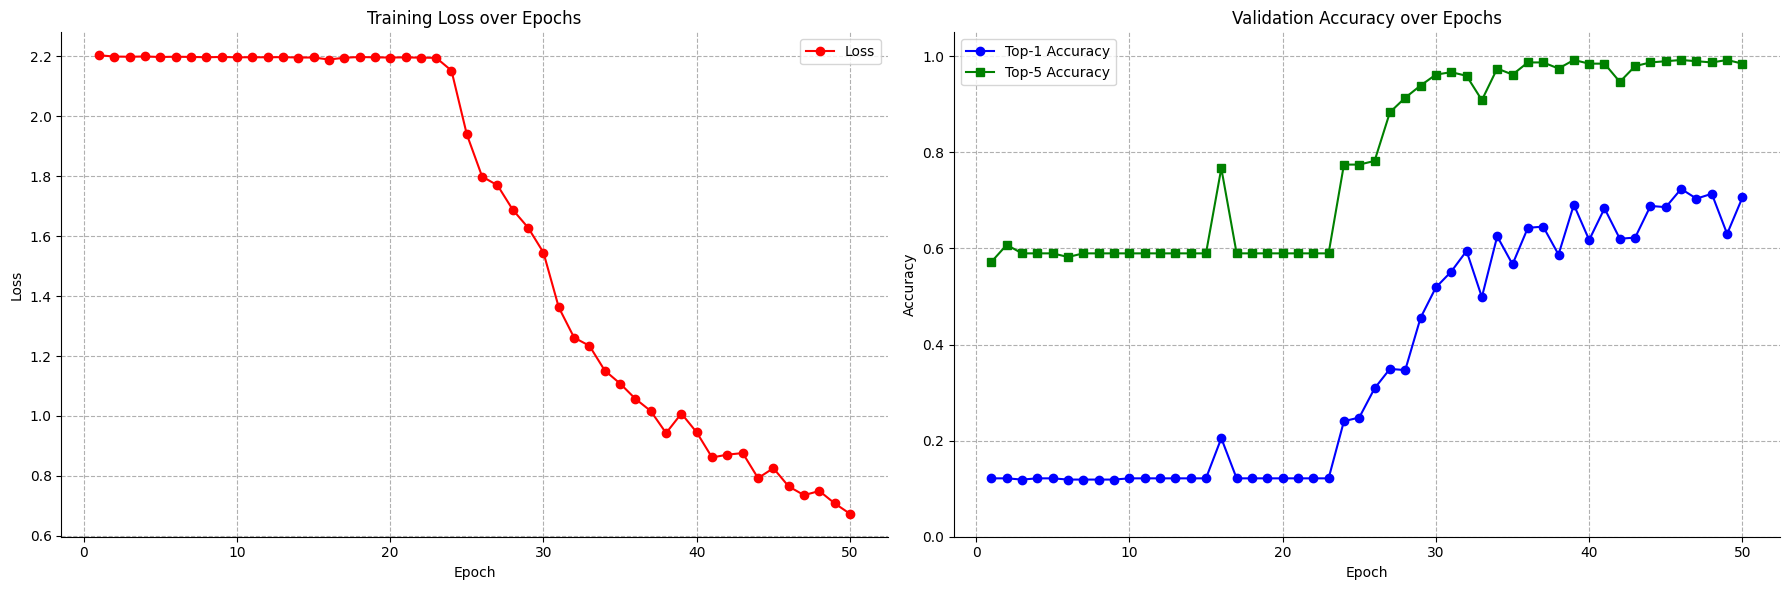

In [ ]:
# --- 繪製訓練過程圖表 ---
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(18, 6))

# 左圖: Loss
ax1 = plt.subplot(1, 2, 1) # <--- 獲取第一個子圖的 Axes 對象
ax1.plot(epochs_range, epoch_train_loss_list, 'r-o', label='Loss')
ax1.set_title('Training Loss over Epochs') # 或 'Loss over Epochs'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--')
# --- 去除上邊框和右邊框 ---
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
# --------------------------

# 右圖: 驗證準確率
ax2 = plt.subplot(1, 2, 2) # <--- 獲取第二個子圖的 Axes 對象
ax2.plot(epochs_range, epoch_val_accuracy_list, 'b-o', label='Top-1 Accuracy')
# ... (如果你有 Top-5 準確率，也繪製到 ax2 上)
if epoch_val_top5_accuracy_list: # 檢查列表是否為空
   ax2.plot(epochs_range, epoch_val_top5_accuracy_list, 'g-s', label='Top-5 Accuracy')
ax2.set_title('Validation Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, linestyle='--')
# --- 去除上邊框和右邊框 ---
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
# --------------------------

plt.tight_layout()
plt.show()


--- Evaluating on Test Set using the Best Model ---
Final Test Accuracy: 0.7136

Classification Report on Test Set:
              precision    recall  f1-score   support

       Black       0.67      0.62      0.64        26
        Blue       0.89      0.92      0.91        26
       Green       0.70      0.80      0.74        20
        Grey       0.41      0.54      0.46        24
      Orange       0.95      0.79      0.86        24
         Red       0.81      0.88      0.84        24
      Silver       0.40      0.17      0.24        23
       White       0.61      0.83      0.70        23
      Yellow       1.00      0.87      0.93        23

    accuracy                           0.71       213
   macro avg       0.71      0.71      0.70       213
weighted avg       0.72      0.71      0.71       213


Confusion Matrix on Test Set:


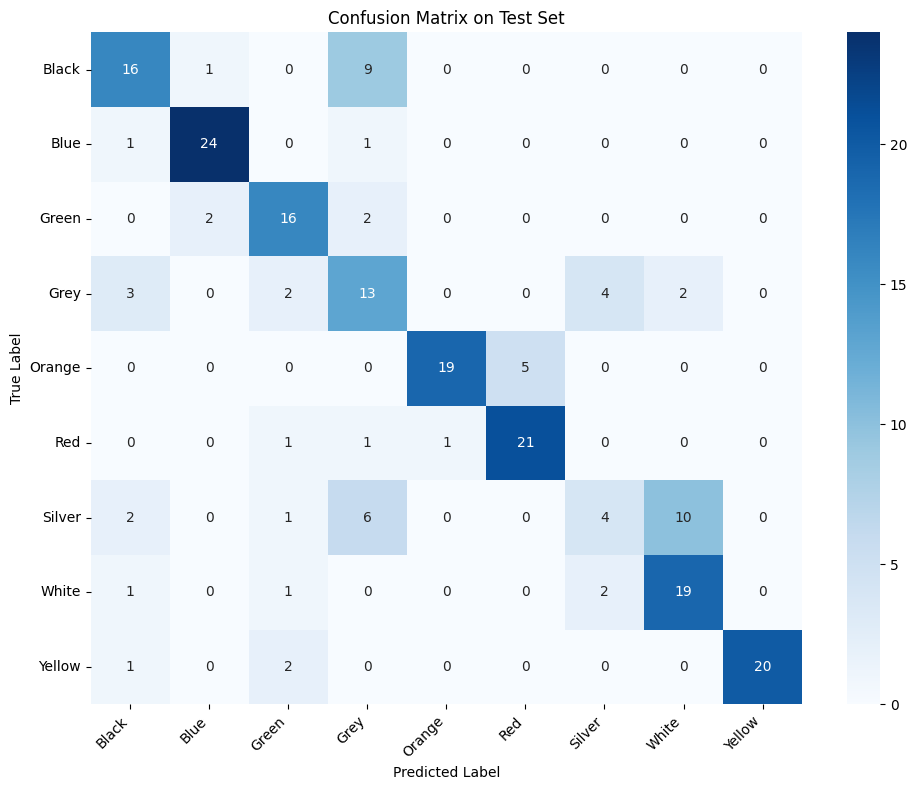

In [ ]:
# --- 在測試集上評估最終選定的模型 (通常是 best_val_accuracy 對應的模型) ---
# (這部分代碼與上一個回答中的相同，此處省略以避免重複，請參考上一個回答的最後部分)
# ... (載入 best_model, 在 test_loader 上評估, 打印 Classification Report 和 Confusion Matrix) ...
# 確保在測試集評估前，將 best_model = ViTForImageClassification(...) 實例化並加載權重
print("\n--- Evaluating on Test Set using the Best Model ---")
best_model = ViTForImageClassification(len(train_ds.classes))
best_model.load_state_dict(torch.load('/content/best_model_statedict.pt'))
best_model.to(device)
best_model.eval()

correct_test_preds = 0
total_test_samples = 0
all_test_labels_list = []
all_test_preds_list = []

with torch.no_grad():
    for test_x_batch, test_y_batch in test_loader:
        current_batch_size_test = test_x_batch.shape[0]
        images_for_extractor_test = []
        test_x_np_batch = test_x_batch.cpu().numpy()
        for i in range(current_batch_size_test):
            img_np_test = test_x_np_batch[i]
            images_for_extractor_test.append(np.squeeze(img_np_test))

        test_x_processed = torch.tensor(np.stack(feature_extractor(images_for_extractor_test)['pixel_values'], axis=0))
        test_x_processed = test_x_processed.to(device)

        outputs_test, _ = best_model(test_x_processed, None)

        _, preds_test = torch.max(outputs_test.cpu(), 1)

        correct_test_preds += torch.sum(preds_test == test_y_batch.data)
        total_test_samples += test_y_batch.size(0)

        all_test_labels_list.extend(test_y_batch.numpy())
        all_test_preds_list.extend(preds_test.numpy())

final_test_accuracy = correct_test_preds.double() / total_test_samples
print(f"Final Test Accuracy: {final_test_accuracy:.4f}")

print("\nClassification Report on Test Set:")
print(classification_report(all_test_labels_list, all_test_preds_list, target_names=class_names, zero_division=0))

print("\nConfusion Matrix on Test Set:")
cm = confusion_matrix(all_test_labels_list, all_test_preds_list)
plt.figure(figsize=(max(10, len(class_names)), max(8, int(len(class_names)*0.8)))) # 動態調整大小
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.xticks(rotation=45, ha='right') # 旋轉x軸標籤以防重疊
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Evaluate on a Test Image

Finally, let's evaluate the model on a test image:

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


torch.Size([1, 3, 224, 224])


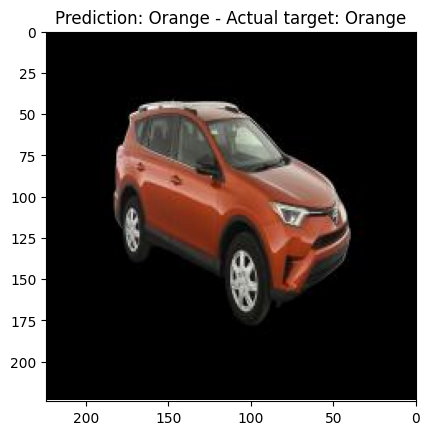

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

EVAL_BATCH = 1
eval_loader  = data.DataLoader(valid_ds, batch_size=EVAL_BATCH, shuffle=True, num_workers=4)
# Disable grad
with torch.no_grad():

  inputs, target = next(iter(eval_loader))
  # Reshape and get feature matrices as needed
  print(inputs.shape)
  inputs = inputs[0].permute(1, 2, 0)
  # Save original Input
  originalInput = inputs
  for index, array in enumerate(inputs):
    inputs[index] = np.squeeze(array)
  inputs = torch.tensor(np.stack(feature_extractor(inputs)['pixel_values'], axis=0))

  # Send to appropriate computing device
  inputs = inputs.to(device)
  target = target.to(device)

  # Generate prediction
  prediction, loss = model(inputs, target)

  # Predicted class value using argmax
  predicted_class = np.argmax(prediction.cpu())
  value_predicted = list(valid_ds.class_to_idx.keys())[list(valid_ds.class_to_idx.values()).index(predicted_class)]
  value_target = list(valid_ds.class_to_idx.keys())[list(valid_ds.class_to_idx.values()).index(target)]

  # Show result
  plt.imshow(originalInput)
  plt.xlim(224,0)
  plt.ylim(224,0)
  plt.title(f'Prediction: {value_predicted} - Actual target: {value_target}')
  plt.show()

## Save the Entire Model

We can save the entire model as follows:

In [ ]:
# torch.save(model, '/content/model.pt')

## Export Trained Model

Now that you have trained your custom vision transformer, you can export the trained model you have made here for inference on your device elsewhere

In [ ]:
# from google.colab import drive
# drive.mount('/content/gdrive')

# %cp /content/model.pt /content/gdrive/My\ Drive

## Use your Exported Model

In [ ]:
# MODEL_PATH = '/content/model.pt'
# model = torch.load(MODEL_PATH)
# model.eval()